In [20]:
from pathlib import Path
from collections import Counter
import random
import math
import yaml

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
sns.set_theme(style="whitegrid")

DATASET_ROOT = Path("Trash Detection Dataset/CUSTOM_DATASET")
DATA_YAML = DATASET_ROOT / "data.yaml"

SPLITS = {
    "train": {
        "images": DATASET_ROOT / "train/images",
        "labels": DATASET_ROOT / "train/labels",
    },
    "valid": {
        "images": DATASET_ROOT / "valid/images",
        "labels": DATASET_ROOT / "valid/labels",
    },
    "test": {
        "images": DATASET_ROOT / "test/images",
        "labels": DATASET_ROOT / "test/labels",
    },
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

SMALL_BOX_AREA = 0.01     # < 1% powierzchni obrazu
LARGE_BOX_AREA = 0.50     # > 50% powierzchni obrazu

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [22]:
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

names = data_config["names"]


if isinstance(names, list):
    CLASS_NAMES = {i: name for i, name in enumerate(names)}
else:
    CLASS_NAMES = {int(i): name for i, name in names.items()}

print("Klasy:")
for class_id, class_name in CLASS_NAMES.items():
    print(f"{class_id}: {class_name}")

Klasy:
0: BIODEGRADABLE
1: CARDBOARD
2: GLASS
3: METAL
4: PAPER
5: PLASTIC


In [23]:
def analyze_split(split_name, images_dir, labels_dir):
    image_paths = sorted([
        path for path in images_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    label_paths = sorted(labels_dir.glob("*.txt"))

    image_stems = {p.stem for p in image_paths}
    label_stems = {p.stem for p in label_paths}

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems
    image_rows = []
    box_rows = []
    error_rows = []
    class_counts = Counter()
    empty_labels = []
    broken_images = []

    for image_path in image_paths:
        image = cv2.imread(str(image_path))
        if image is None:
            broken_images.append(str(image_path))
            error_rows.append({
                "split": split_name,
                "file": image_path.name,
                "error": "broken_image"
            })
            continue

        height, width = image.shape[:2]

        label_path = labels_dir / f"{image_path.stem}.txt"

        if not label_path.exists():

            image_rows.append({
                "split": split_name,
                "image": image_path.name,
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "objects": 0,
            })

            continue
        with open(label_path, "r", encoding="utf-8") as f:
            lines = [
                line.strip()
                for line in f.readlines()
                if line.strip()
            ]

        if len(lines) == 0:
            empty_labels.append(label_path.name)

        valid_objects = 0

        for line_number, line in enumerate(lines, start=1):

            values = line.split()

            if len(values) != 5:

                error_rows.append({
                    "split": split_name,
                    "file": label_path.name,
                    "line": line_number,
                    "error": "wrong_number_of_values",
                    "value": line
                })

                continue

            try:

                class_id = int(float(values[0]))

                x_center = float(values[1])
                y_center = float(values[2])
                box_width = float(values[3])
                box_height = float(values[4])

            except ValueError:

                error_rows.append({
                    "split": split_name,
                    "file": label_path.name,
                    "line": line_number,
                    "error": "invalid_number",
                    "value": line
                })

                continue

            values_numeric = [
                x_center,
                y_center,
                box_width,
                box_height
            ]
            if not all(math.isfinite(v) for v in values_numeric):

                error_rows.append({
                    "split": split_name,
                    "file": label_path.name,
                    "line": line_number,
                    "error": "nan_or_inf"
                })

                continue

            if class_id not in CLASS_NAMES:

                error_rows.append({
                    "split": split_name,
                    "file": label_path.name,
                    "line": line_number,
                    "error": "invalid_class_id",
                    "class_id": class_id
                })

                continue

            box_errors = []

            if not 0 <= x_center <= 1:
                box_errors.append("x_center_out_of_range")

            if not 0 <= y_center <= 1:
                box_errors.append("y_center_out_of_range")

            if box_width <= 0 or box_width > 1:
                box_errors.append("invalid_width")

            if box_height <= 0 or box_height > 1:
                box_errors.append("invalid_height")

            x1 = x_center - box_width / 2
            y1 = y_center - box_height / 2
            x2 = x_center + box_width / 2
            y2 = y_center + box_height / 2

            if x1 < 0 or y1 < 0 or x2 > 1 or y2 > 1:
                box_errors.append("box_outside_image")

            for error in box_errors:

                error_rows.append({
                    "split": split_name,
                    "file": label_path.name,
                    "line": line_number,
                    "error": error
                })

            if box_errors:
                continue

            box_width_px = box_width * width
            box_height_px = box_height * height

            box_area_ratio = box_width * box_height
            box_area_px = box_width_px * box_height_px

            class_counts[class_id] += 1
            valid_objects += 1

            box_rows.append({
                "split": split_name,
                "image": image_path.name,

                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],

                "x_center": x_center,
                "y_center": y_center,

                "width_norm": box_width,
                "height_norm": box_height,

                "width_px": box_width_px,
                "height_px": box_height_px,

                "area_ratio": box_area_ratio,
                "area_px": box_area_px,

                "box_aspect_ratio": box_width / box_height,

                "is_small": box_area_ratio < SMALL_BOX_AREA,
                "is_large": box_area_ratio > LARGE_BOX_AREA,
            })

        image_rows.append({
            "split": split_name,
            "image": image_path.name,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "objects": valid_objects,
        })

    images_df = pd.DataFrame(image_rows)
    boxes_df = pd.DataFrame(box_rows)
    errors_df = pd.DataFrame(error_rows)

    summary = {
        "split": split_name,

        "images": len(image_paths),
        "labels": len(label_paths),

        "bounding_boxes": len(boxes_df),

        "missing_labels": len(missing_labels),
        "orphan_labels": len(orphan_labels),

        "empty_labels": len(empty_labels),
        "broken_images": len(broken_images),

        "annotation_errors": len(errors_df),

        "class_counts": dict(class_counts)
    }

    return {
        "summary": summary,
        "images": images_df,
        "boxes": boxes_df,
        "errors": errors_df,
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
        "empty_labels": empty_labels,
        "broken_images": broken_images,
    }

In [24]:
results = {}

for split_name, paths in SPLITS.items():
    results[split_name] = analyze_split(
        split_name,
        paths["images"],
        paths["labels"]
    )

In [25]:
summary_rows = []

for split_name, result in results.items():

    s = result["summary"]

    images_df = result["images"]

    summary_rows.append({
        "split": split_name,
        "images": s["images"],
        "labels": s["labels"],
        "bounding_boxes": s["bounding_boxes"],

        "avg_objects_per_image": (
            images_df["objects"].mean()
            if len(images_df)
            else 0
        ),

        "min_objects_per_image": (
            images_df["objects"].min()
            if len(images_df)
            else 0
        ),

        "max_objects_per_image": (
            images_df["objects"].max()
            if len(images_df)
            else 0
        ),

        "missing_labels": s["missing_labels"],
        "orphan_labels": s["orphan_labels"],
        "empty_labels": s["empty_labels"],
        "broken_images": s["broken_images"],
        "annotation_errors": s["annotation_errors"],
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,split,images,labels,bounding_boxes,avg_objects_per_image,min_objects_per_image,max_objects_per_image,missing_labels,orphan_labels,empty_labels,broken_images,annotation_errors
0,train,3565,3566,22354,6.270407,0,293,29,30,3,0,1158
1,valid,1008,1008,7284,7.226190,1,311,0,0,0,0,0
2,test,505,505,3286,6.506931,1,271,0,0,0,0,0


In [26]:
all_boxes_df = pd.concat(
    [results[s]["boxes"] for s in results],
    ignore_index=True
)

class_distribution = (
    all_boxes_df
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="objects")
)

display(class_distribution)

,split,class_name,objects
0,test,BIODEGRADABLE,1545
1,test,CARDBOARD,273
2,test,GLASS,437
3,test,METAL,436
4,test,PAPER,204
5,test,PLASTIC,391
6,train,BIODEGRADABLE,12128
7,train,CARDBOARD,1957
8,train,GLASS,1503
9,train,METAL,2536


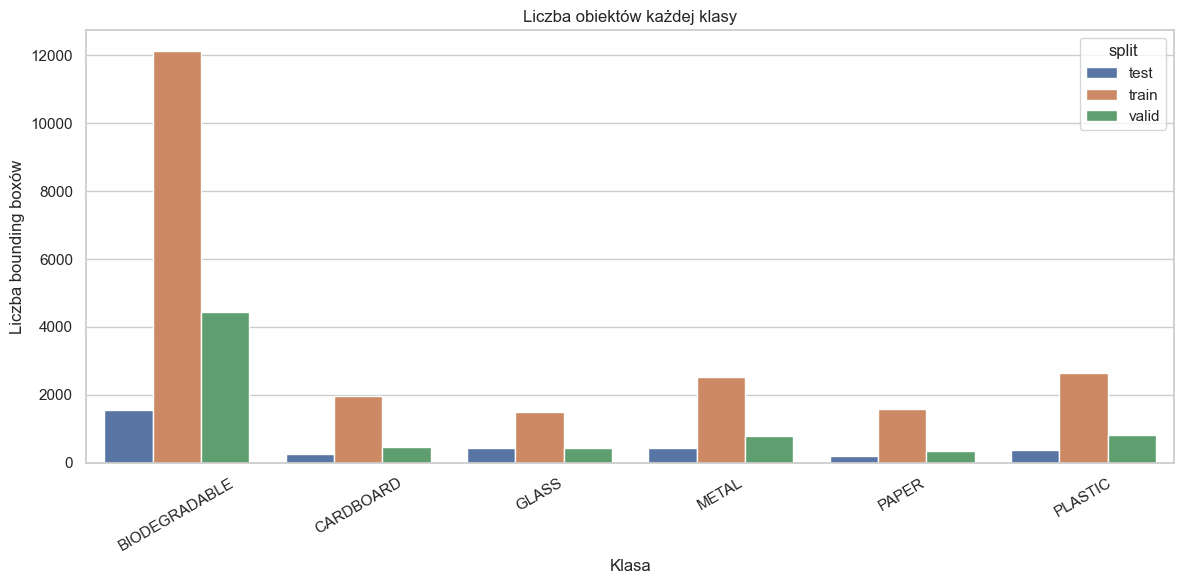

In [27]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=class_distribution,
    x="class_name",
    y="objects",
    hue="split"
)

plt.title("Liczba obiektów każdej klasy")
plt.xlabel("Klasa")
plt.ylabel("Liczba bounding boxów")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [28]:
overall_class_counts = (
    all_boxes_df["class_name"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="objects")
)

overall_class_counts["percentage"] = (
    overall_class_counts["objects"]
    / overall_class_counts["objects"].sum() * 100
)

display(overall_class_counts)

,class,objects,percentage
0,BIODEGRADABLE,18123,55.044952
1,PLASTIC,3846,11.681448
2,METAL,3761,11.423278
3,CARDBOARD,2681,8.142996
4,GLASS,2372,7.204471
5,PAPER,2141,6.502855


In [29]:
max_class = overall_class_counts.iloc[0]
min_class = overall_class_counts.iloc[-1]

imbalance_ratio = (
    max_class["objects"]
    / min_class["objects"]
)

print(
    f"Największa klasa: {max_class['class']} "
    f"({max_class['objects']})"
)

print(
    f"Najmniejsza klasa: {min_class['class']} "
    f"({min_class['objects']})"
)

print(
    f"Imbalance ratio: {imbalance_ratio:.2f}:1"
)

Największa klasa: BIODEGRADABLE (18123)
Najmniejsza klasa: PAPER (2141)
Imbalance ratio: 8.46:1


In [30]:
all_images_df = pd.concat(
    [results[s]["images"] for s in results],
    ignore_index=True
)

display(
    all_images_df
    .groupby("split")["objects"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,505.0,6.506931,18.451686,1.0,1.0,1.0,4.0,271.0
train,3565.0,6.270407,19.121483,0.0,1.0,1.0,4.0,293.0
valid,1008.0,7.226190,21.541038,1.0,1.0,2.0,4.0,311.0


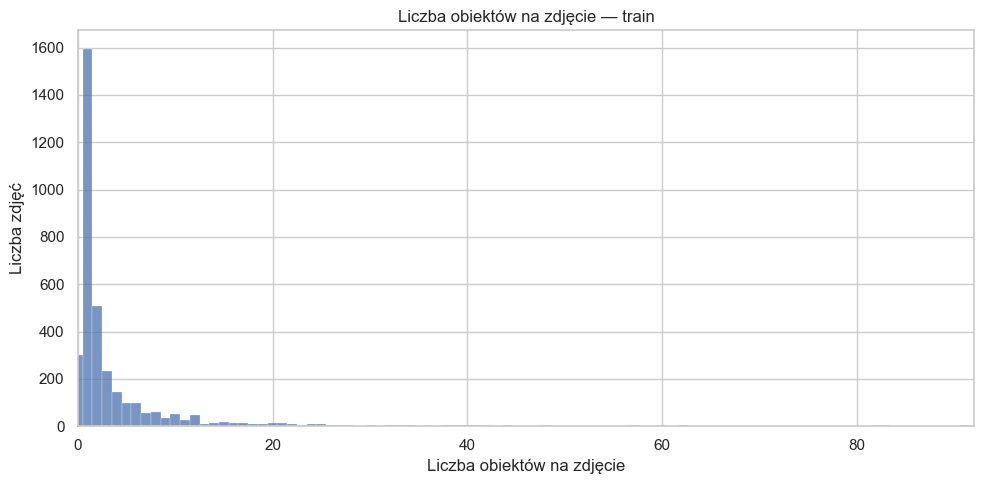

train: 99% zdjęć ma maksymalnie 92 obiektów
Maksymalna liczba obiektów na jednym zdjęciu: 293



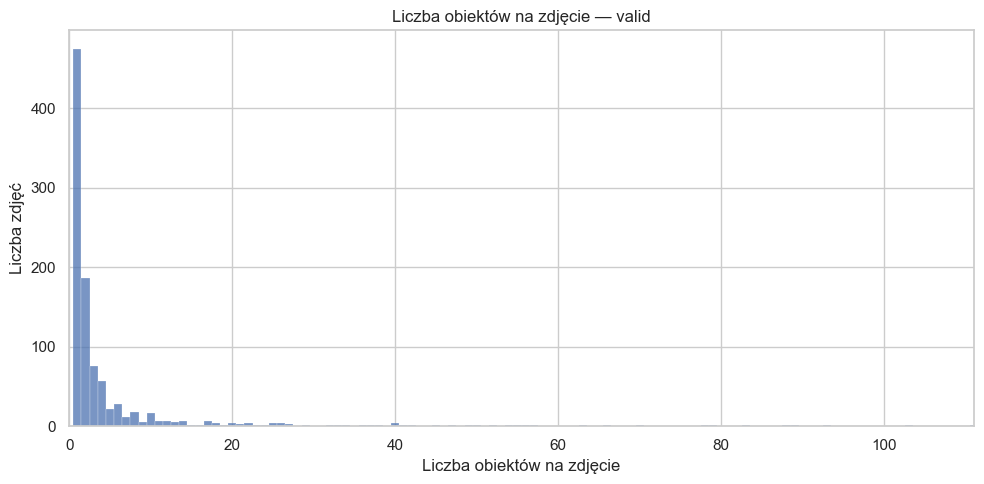

valid: 99% zdjęć ma maksymalnie 111 obiektów
Maksymalna liczba obiektów na jednym zdjęciu: 311



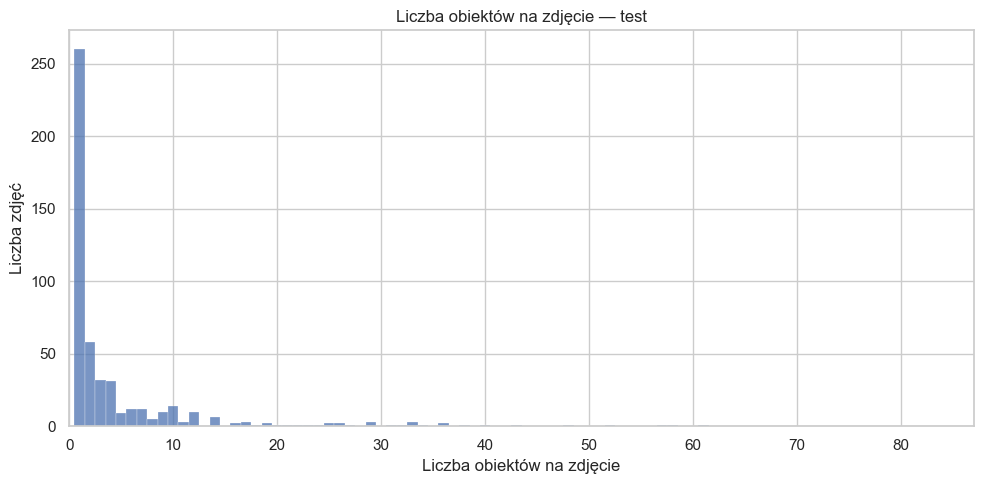

test: 99% zdjęć ma maksymalnie 87 obiektów
Maksymalna liczba obiektów na jednym zdjęciu: 271



In [31]:
for split in ["train", "valid", "test"]:
    
    split_df = all_images_df[
        all_images_df["split"] == split
    ]

    # 99 percentyl tylko do ustawienia zakresu wykresu
    x_max = int(
        np.ceil(split_df["objects"].quantile(0.99))
    )

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=split_df,
        x="objects",
        discrete=True,
        binwidth=1
    )

    plt.xlim(0, x_max)

    plt.title(f"Liczba obiektów na zdjęcie — {split}")
    plt.xlabel("Liczba obiektów na zdjęcie")
    plt.ylabel("Liczba zdjęć")

    plt.tight_layout()
    plt.show()

    print(
        f"{split}: 99% zdjęć ma maksymalnie "
        f"{x_max} obiektów"
    )

    print(
        f"Maksymalna liczba obiektów na jednym zdjęciu: "
        f"{split_df['objects'].max()}"
    )

    print()

In [32]:
resolution_counts = (
    all_images_df
    .groupby(["split", "width", "height"])
    .size()
    .reset_index(name="images")
    .sort_values(
        ["split", "images"],
        ascending=[True, False]
    )
)

display(resolution_counts)

,split,width,height,images
0,test,640,640,505
1,train,640,640,3565
2,valid,640,640,1008


In [33]:
display(
    all_boxes_df[
        [
            "width_norm",
            "height_norm",
            "area_ratio",
            "box_aspect_ratio"
        ]
    ].describe()
)

,width_norm,height_norm,area_ratio,box_aspect_ratio
count,32924.000000,32924.000000,32924.000000,32924.000000
mean,0.231622,0.242950,0.102125,1.207994
std,0.250547,0.254377,0.198392,1.107401
min,0.006250,0.004687,0.000088,0.036514
25%,0.061328,0.067187,0.004155,0.596899
50%,0.122656,0.134375,0.016769,0.931034
75%,0.300781,0.317188,0.091597,1.447696
max,1.000000,1.000000,0.995317,28.555556


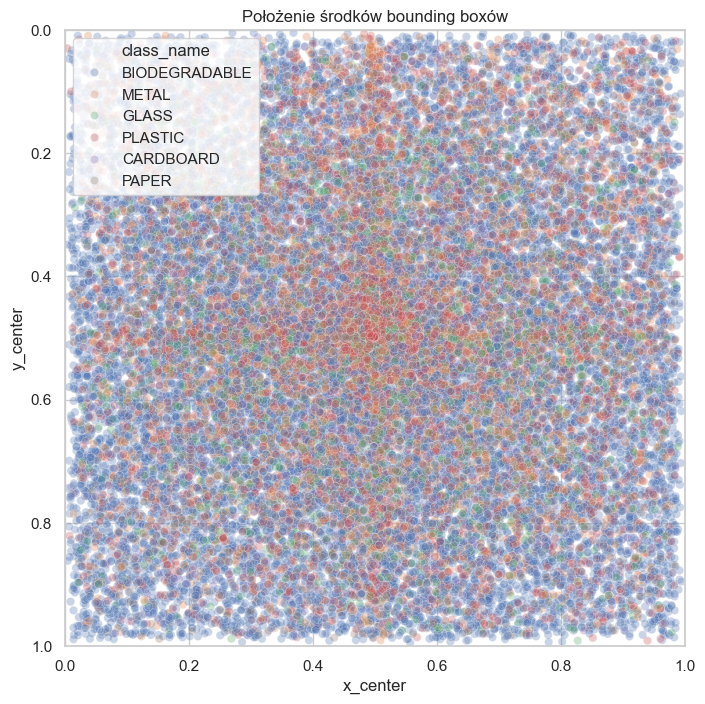

In [34]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=all_boxes_df,
    x="x_center",
    y="y_center",
    hue="class_name",
    alpha=0.3
)

plt.xlim(0, 1)
plt.ylim(1, 0)

plt.title("Położenie środków bounding boxów")
plt.xlabel("x_center")
plt.ylabel("y_center")

plt.show()

In [35]:
for split_name, result in results.items():

    print(f"\nerror_df{split_name.upper()}")

    print(
        "Brak labela:",
        len(result["missing_labels"])
    )

    print(
        "Label bez zdjęcia:",
        len(result["orphan_labels"])
    )

    print(
        "Puste labele:",
        len(result["empty_labels"])
    )

    print(
        "Uszkodzone zdjęcia:",
        len(result["broken_images"])
    )

    print(
        "Błędy adnotacji:",
        len(result["errors"])
    )


TRAIN
Brak labela: 29
Label bez zdjęcia: 30
Puste labele: 3
Uszkodzone zdjęcia: 0
Błędy adnotacji: 1158

VALID
Brak labela: 0
Label bez zdjęcia: 0
Puste labele: 0
Uszkodzone zdjęcia: 0
Błędy adnotacji: 0

TEST
Brak labela: 0
Label bez zdjęcia: 0
Puste labele: 0
Uszkodzone zdjęcia: 0
Błędy adnotacji: 0


In [36]:
all_errors_df = pd.concat(
    [results[s]["errors"] for s in results],
    ignore_index=True
)

display(all_errors_df.head(30))

,split,file,line,error,value
0,train,biodegradable100_jpg.rf.6ed8f492f63f576ff6e778...,1,wrong_number_of_values,0 0.93359375 0.2548828125 0.90234375 0.1650390...
1,train,biodegradable100_jpg.rf.6ed8f492f63f576ff6e778...,2,wrong_number_of_values,0 0.474759615625 0.29296875 0.4507211531250000...
2,train,biodegradable100_jpg.rf.6ed8f492f63f576ff6e778...,3,wrong_number_of_values,0 0.701171875 0.6435546875 0.673828125 0.59082...
3,train,biodegradable101_jpg.rf.0d85840d2e9ffdfab68d9e...,1,wrong_number_of_values,0 0.67578125 0.3095703125 0.6259765625 0.24218...
4,train,biodegradable101_jpg.rf.0d85840d2e9ffdfab68d9e...,2,wrong_number_of_values,0 0.884765625 0.5302734375 0.8056640625 0.4960...
5,train,biodegradable101_jpg.rf.0d85840d2e9ffdfab68d9e...,3,wrong_number_of_values,0 0.55438701875 0.743689903125 0.528846153125 ...
6,train,biodegradable101_jpg.rf.0d85840d2e9ffdfab68d9e...,4,wrong_number_of_values,0 0.2880859375 0.603515625 0.2734375 0.6044921...
7,train,biodegradable101_jpg.rf.0d85840d2e9ffdfab68d9e...,5,wrong_number_of_values,0 0.443359375 0.6650390625 0.4582331734375 0.6...
8,train,biodegradable102_jpg.rf.63caed0a09dd140d26dfbc...,1,wrong_number_of_values,0 0.798828125 0.3935546875 0.80078125 0.305664...
9,train,biodegradable102_jpg.rf.63caed0a09dd140d26dfbc...,2,wrong_number_of_values,0 0.923828125 0.4521484375 0.91796875 0.586914...
